In [147]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
import tarfile
import pickle
import os

In [148]:
def load_cifar10_manual(file_path):
    with tarfile.open(file_path, "r:gz") as tar:
        tar.extractall()

    def unpickle(file):
        with open(file, 'rb') as fo:
            dict_data = pickle.load(fo, encoding='bytes')
        return dict_data

    x_train_list = []
    y_train_list = []
    for i in range(1, 6):
        batch = unpickle(f'cifar-10-batches-py/data_batch_{i}')
        x_train_list.append(batch[b'data'])
        y_train_list.append(batch[b'labels'])
        
    test_batch = unpickle('cifar-10-batches-py/test_batch')
    x_test = test_batch[b'data']
    y_test = np.array(test_batch[b'labels'])

    x_train = np.concatenate(x_train_list)
    x_train = x_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    
    y_train = np.concatenate(y_train_list)
    
    x_test = x_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    return (x_train, y_train), (x_test, y_test)

(x_train, y_train), (x_test, y_test) = load_cifar10_manual('cifar-10-python.tar.gz')

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape) 


C:\Users\Erfan\AppData\Local\Temp\ipykernel_4784\1327816814.py:3: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


x_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)


In [149]:
x_train

array([[[[ 59,  62,  63],
         [ 43,  46,  45],
         [ 50,  48,  43],
         ...,
         [158, 132, 108],
         [152, 125, 102],
         [148, 124, 103]],

        [[ 16,  20,  20],
         [  0,   0,   0],
         [ 18,   8,   0],
         ...,
         [123,  88,  55],
         [119,  83,  50],
         [122,  87,  57]],

        [[ 25,  24,  21],
         [ 16,   7,   0],
         [ 49,  27,   8],
         ...,
         [118,  84,  50],
         [120,  84,  50],
         [109,  73,  42]],

        ...,

        [[208, 170,  96],
         [201, 153,  34],
         [198, 161,  26],
         ...,
         [160, 133,  70],
         [ 56,  31,   7],
         [ 53,  34,  20]],

        [[180, 139,  96],
         [173, 123,  42],
         [186, 144,  30],
         ...,
         [184, 148,  94],
         [ 97,  62,  34],
         [ 83,  53,  34]],

        [[177, 144, 116],
         [168, 129,  94],
         [179, 142,  87],
         ...,
         [216, 184, 140],
        

$$Mean\_Image_{x,y,c} = \frac{1}{N} \sum_{i=1}^{N} I(i, x, y, c)$$

In [150]:
x_train = x_train.astype(np.float64)
mean_img = np.sum(x_train, axis=0)/x_train.shape[0]
mean_img

array([[[130.71074, 136.05614, 132.5538 ],
        [130.14036, 135.44238, 131.85358],
        [131.05044, 136.24616, 132.58144],
        ...,
        [131.05902, 136.307  , 132.44078],
        [130.39308, 135.70848, 132.00036],
        [130.174  , 135.4736 , 131.89246]],

       [[130.0993 , 135.29484, 131.36412],
        [129.3446 , 134.45914, 130.4656 ],
        [130.2169 , 135.1767 , 131.10234],
        ...,
        [130.04254, 135.13862, 130.90018],
        [129.33038, 134.55898, 130.49918],
        [129.1568 , 134.38368, 130.45104]],

       [[129.72472, 134.64818, 130.2514 ],
        [128.71662, 133.49748, 129.01922],
        [129.47348, 134.05546, 129.47586],
        ...,
        [129.21066, 133.95824, 129.29398],
        [128.59094, 133.54152, 129.06528],
        [128.59134, 133.55772, 129.22356]],

       ...,

       [[126.55372, 125.9533 , 114.1421 ],
        [124.58844, 123.7335 , 111.77894],
        [123.92508, 122.8011 , 110.73544],
        ...,
        [124.24036, 123.00

In [151]:
np.mean(x_train, axis=0)

array([[[130.71074, 136.05614, 132.5538 ],
        [130.14036, 135.44238, 131.85358],
        [131.05044, 136.24616, 132.58144],
        ...,
        [131.05902, 136.307  , 132.44078],
        [130.39308, 135.70848, 132.00036],
        [130.174  , 135.4736 , 131.89246]],

       [[130.0993 , 135.29484, 131.36412],
        [129.3446 , 134.45914, 130.4656 ],
        [130.2169 , 135.1767 , 131.10234],
        ...,
        [130.04254, 135.13862, 130.90018],
        [129.33038, 134.55898, 130.49918],
        [129.1568 , 134.38368, 130.45104]],

       [[129.72472, 134.64818, 130.2514 ],
        [128.71662, 133.49748, 129.01922],
        [129.47348, 134.05546, 129.47586],
        ...,
        [129.21066, 133.95824, 129.29398],
        [128.59094, 133.54152, 129.06528],
        [128.59134, 133.55772, 129.22356]],

       ...,

       [[126.55372, 125.9533 , 114.1421 ],
        [124.58844, 123.7335 , 111.77894],
        [123.92508, 122.8011 , 110.73544],
        ...,
        [124.24036, 123.00

$$Mean\_Intensity_{x,y,c} = \frac{\sum_{i=1}^{50000} \sum_{x=1}^{32} \sum_{y=1}^{32} I(i, x, y, c)}{50000 \times 32 \times 32}$$


In [152]:
pixels_per_channel = x_train.shape[0]*x_train.shape[1]*x_train.shape[2]
print(pixels_per_channel)
sum_per_channel = np.sum(x_train, axis=(0,1,2))
print(sum_per_channel)
mean_intensity = sum_per_channel / pixels_per_channel
mean_intensity

51200000
[6.41571420e+09 6.29506018e+09 5.82990762e+09]


array([125.30691805, 122.95039414, 113.86538318])

In [153]:
np.mean(x_train, axis=(0,1,2))

array([125.30691805, 122.95039414, 113.86538318])

$$\sigma^2 = \frac{1}{N} \sum (x_i - \mu)^2$$

In [154]:
variance = np.sum((x_train-mean_intensity)**2, axis=(0,1,2)) / pixels_per_channel
variance

array([3968.14567502, 3855.00761641, 4449.54363607])

In [155]:
np.var(x_train, axis=(0,1,2))

array([3968.14567502, 3855.00761641, 4449.54363607])

In [156]:
standard_deviation = np.sqrt(variance)
standard_deviation

array([62.99321928, 62.08870764, 66.70489964])

In [157]:
np.std(x_train, axis=(0,1,2))

array([62.99321928, 62.08870764, 66.70489964])

In [158]:
index = np.random.randint(1,50000)
sample_image = x_train[index]

print(sample_image.shape)
sample_image_flatten = sample_image.flatten()
print(sample_image_flatten.shape)


(32, 32, 3)
(3072,)


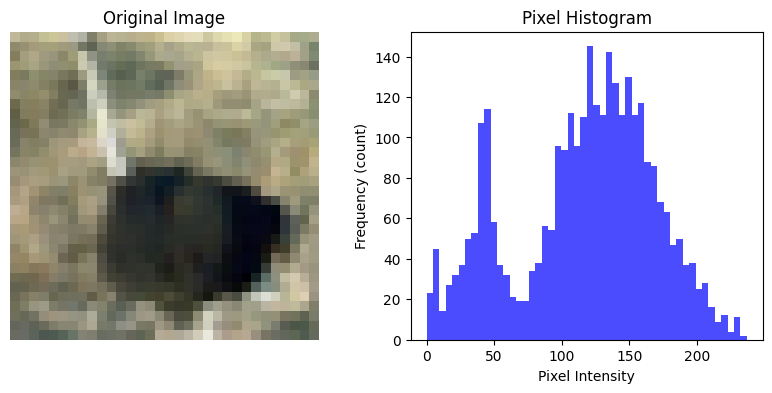

In [159]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

axes[0].imshow(sample_image.astype(np.uint8))
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].hist(sample_image_flatten, bins=50, color='blue', alpha=0.7)
axes[1].set_title("Pixel Histogram")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Frequency (count)")

plt.show()

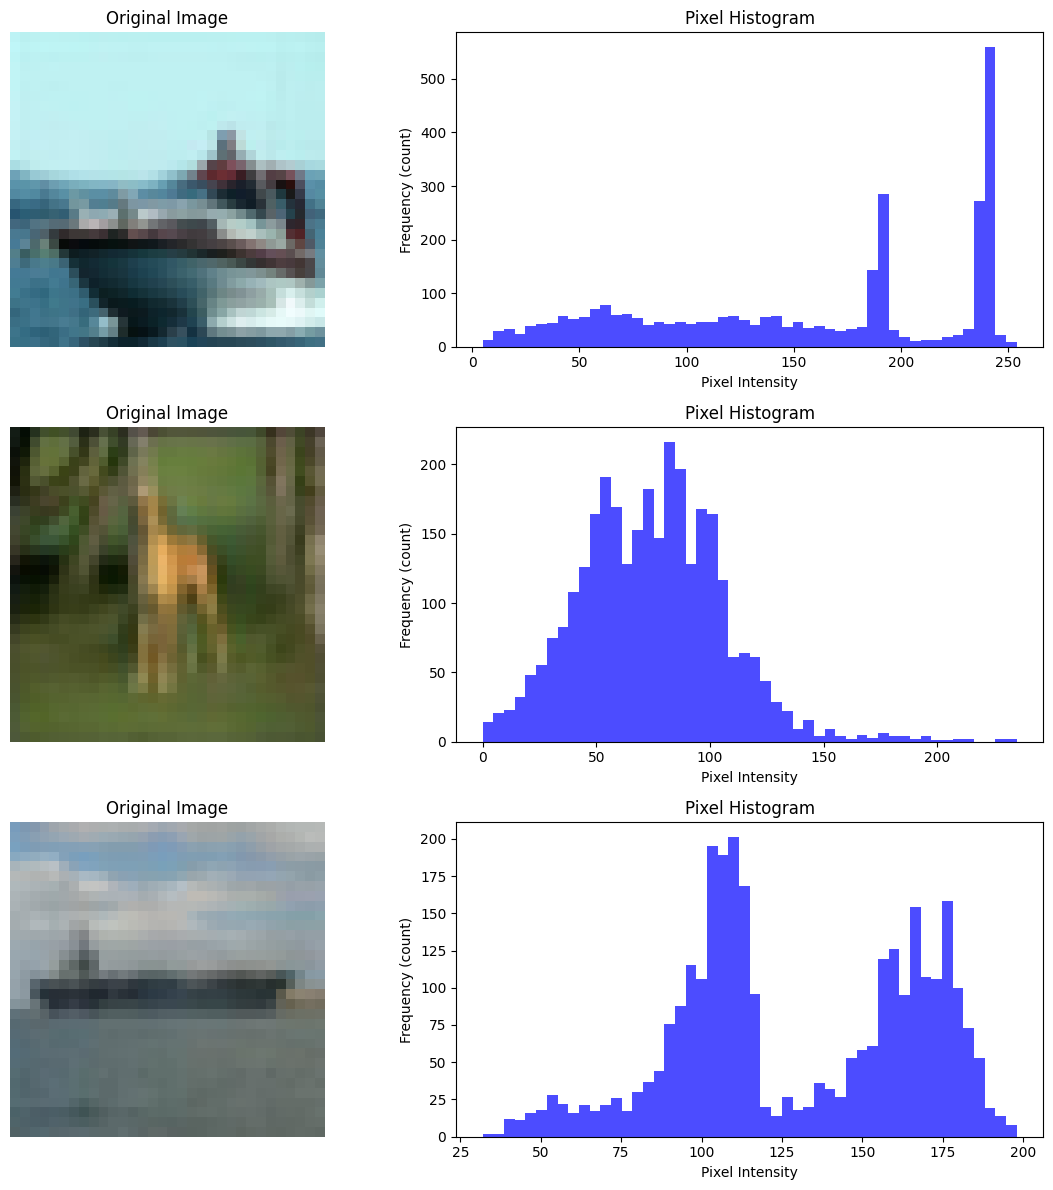

In [160]:
indices = np.random.choice(len(x_train), 3, replace=False)

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for i, idx in enumerate(indices):
    img = x_train[idx]
    img_flatten = img.flatten()
    
    axes[i,0].imshow(img.astype(np.uint8))
    axes[i,0].set_title("Original Image")
    axes[i,0].axis('off')

    axes[i,1].hist(img_flatten, bins=50, color='blue', alpha=0.7)
    axes[i,1].set_title("Pixel Histogram")
    axes[i,1].set_xlabel("Pixel Intensity")
    axes[i,1].set_ylabel("Frequency (count)")
    
plt.tight_layout()
plt.show()
    

Scale 10 -> Mean: 116.44, Variance: 2752.80
Scale 25 -> Mean: 116.10, Variance: 3156.95
Scale 50 -> Mean: 117.21, Variance: 4525.03


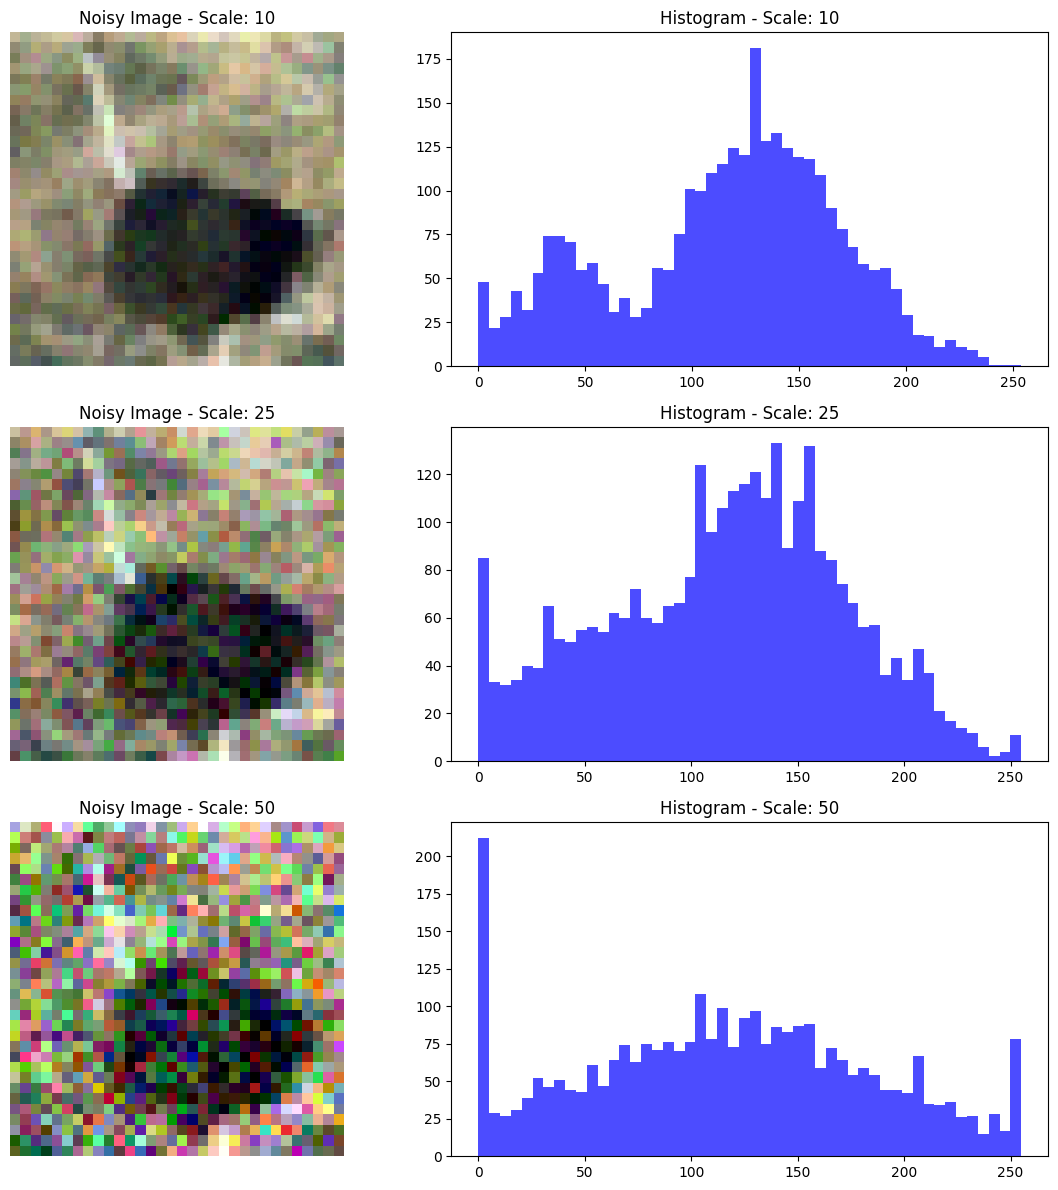

In [161]:
scales = [10, 25, 50]
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for i, scale in enumerate(scales):
    noise_image = np.random.normal(loc=0, scale=scale, size=sample_image.shape)
    
    noisy_sample = sample_image + noise_image
    
    noisy_sample_clipped = np.clip(noisy_sample, 0, 255).astype(np.uint8)
    noisy_sample_flatten = noisy_sample_clipped.flatten()
    
    axes[i, 0].imshow(noisy_sample_clipped)
    axes[i, 0].set_title(f"Noisy Image - Scale: {scale}")
    axes[i, 0].axis('off')
    
    axes[i, 1].hist(noisy_sample_flatten, bins=50, color='blue', alpha=0.7)
    axes[i, 1].set_title(f"Histogram - Scale: {scale}")
    print(f"Scale {scale} -> Mean: {np.mean(noisy_sample_clipped):.2f}, Variance: {np.var(noisy_sample_clipped):.2f}")
    

plt.tight_layout()
plt.show()


**رابطه ریاضی کانولوشن دو بعدی:**<br>
برای تصویر $I$ و کرنل $K$، مقدار پیکسل خروجی در مختصات $(i, j)$ از رابطه زیر محاسبه می‌شود:
$$S(i,j) = (I * K)(i,j) = \sum_m \sum_n I(i+m, j+n) K(m, n)$$

In [162]:
def manual_convolution(image, kernel):
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape
    
    out_h = img_h - k_h + 1
    out_w = img_w - k_w + 1
    
    output = np.zeros((out_h, out_w))
    
    for i in range(out_h):
        for j in range(out_w):
            patch = image[i:i+k_h, j:j+k_w]
            output[i,j] = np.sum(patch*kernel)
            
    return output
    

In [163]:
k_edge_detection = np.array([[-1, 0, 1],
                  [-2, 0, 2],
                  [-1, 0, 1]])

k_blur = np.array([[1/9, 1/9, 1/9],
          [1/9, 1/9, 1/9],
          [1/9, 1/9, 1/9]])

k_sharpen = np.array([[0, -1, 0],
             [-1, 5, -1],
             [0, -1, 0]])


(np.float64(-0.5), np.float64(29.5), np.float64(29.5), np.float64(-0.5))

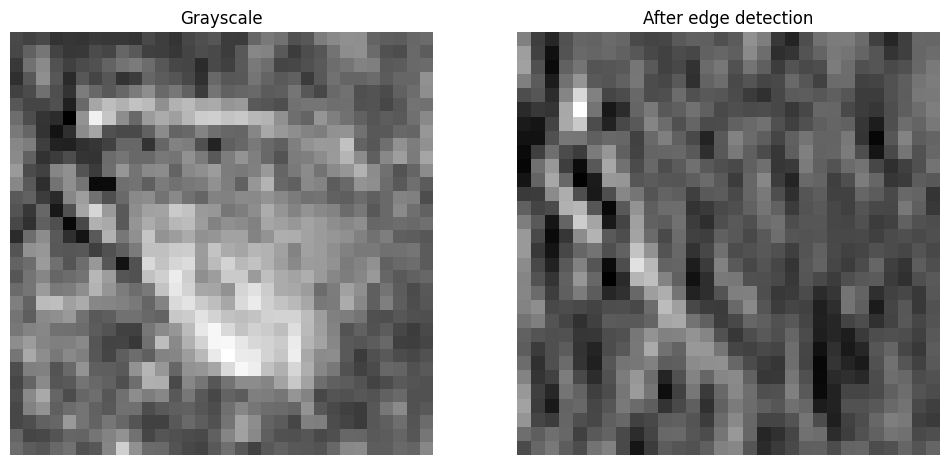

In [164]:
fig, axes = plt.subplots(1, 2, figsize=(12, 12))

idx = np.random.choice(len(x_train))
gray_image = np.dot(x_train[idx],[0.2989, 0.5870, 0.1140])
axes[0].set_title('Grayscale')
axes[0].imshow(gray_image, cmap='gray')

edge_detected_img = manual_convolution(gray_image, k_edge_detection)
axes[1].set_title('After edge detection')
axes[1].imshow(edge_detected_img, cmap='gray')

axes[0].axis('off')
axes[1].axis('off')


show in a better view of plus and negative values

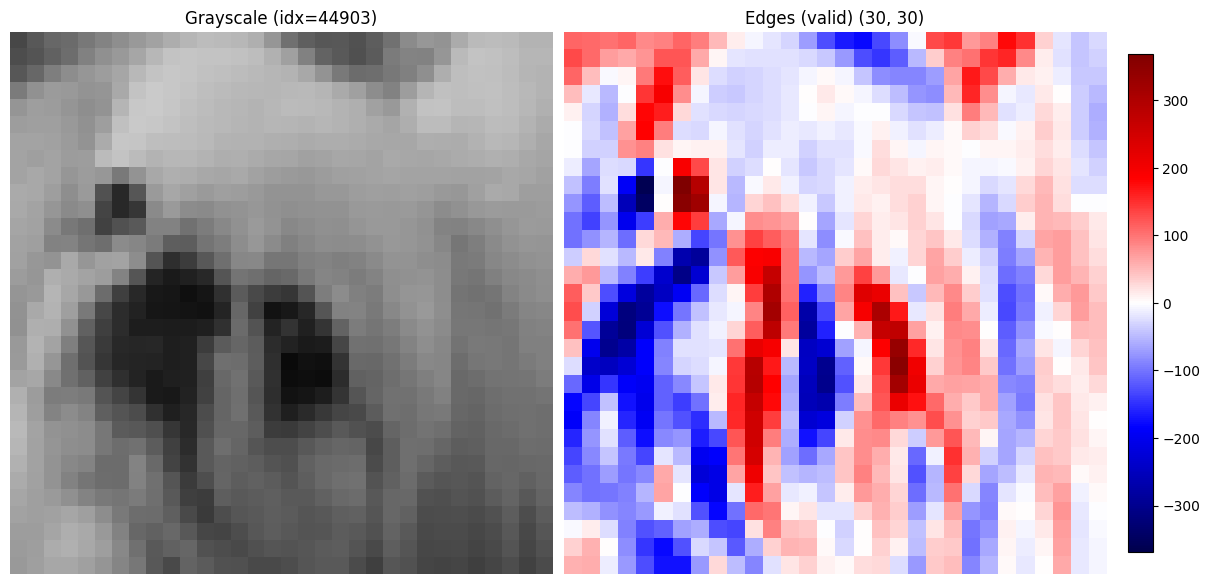

In [165]:
idx = np.random.randint(len(x_train))
img = x_train[idx].astype(np.float32)

gray = img @ np.array([0.2989, 0.5870, 0.1140], dtype=np.float32)

edge = manual_convolution(gray, k_edge_detection)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

axes[0].imshow(gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"Grayscale (idx={idx})")
axes[0].axis("off")

m = np.max(np.abs(edge)) + 1e-8
im = axes[1].imshow(edge, cmap="seismic", vmin=-m, vmax=m)
axes[1].set_title(f"Edges (valid) {edge.shape}")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.show()


(np.float64(-0.5), np.float64(29.5), np.float64(29.5), np.float64(-0.5))

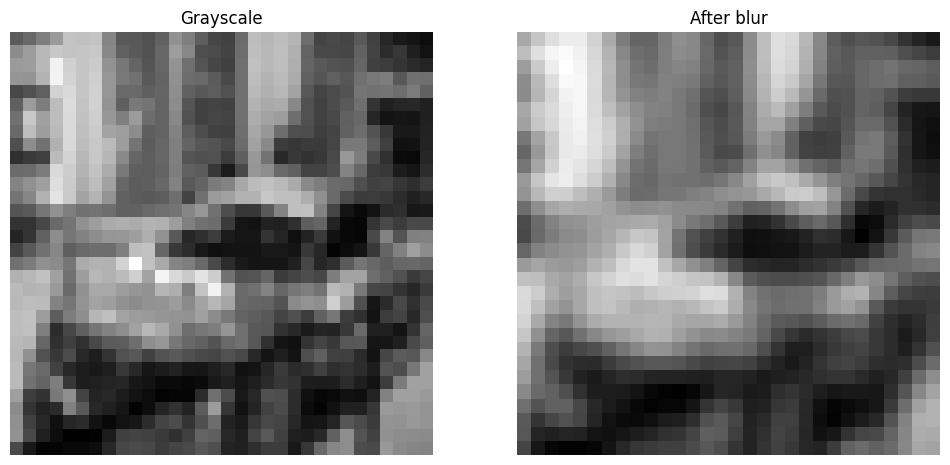

In [166]:
fig, axes = plt.subplots(1, 2, figsize=(12, 12))

idx = np.random.choice(len(x_train))
gray_image = np.dot(x_train[idx],[0.2989, 0.5870, 0.1140])
axes[0].set_title('Grayscale')
axes[0].imshow(gray_image, cmap='gray')

edge_detected_img = manual_convolution(gray_image, k_blur)
axes[1].set_title('After blur')
axes[1].imshow(edge_detected_img, cmap='gray')

axes[0].axis('off')
axes[1].axis('off')


(np.float64(-0.5), np.float64(29.5), np.float64(29.5), np.float64(-0.5))

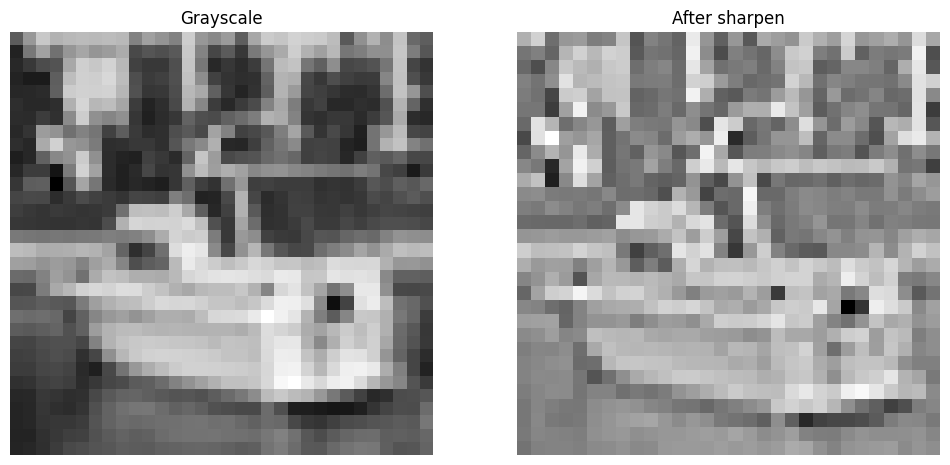

In [167]:
fig, axes = plt.subplots(1, 2, figsize=(12, 12))

idx = np.random.choice(len(x_train))
gray_image = np.dot(x_train[idx],[0.2989, 0.5870, 0.1140])
axes[0].set_title('Grayscale')
axes[0].imshow(gray_image, cmap='gray')
axes[0].axis('off')

edge_detected_img = manual_convolution(gray_image, k_sharpen)
axes[1].set_title('After sharpen')
axes[1].imshow(edge_detected_img, cmap='gray')
axes[1].axis('off')


In [168]:
def im2col_convolution(image, kernel):
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape
    
    out_h = img_h - k_h + 1
    out_w = img_w - k_w + 1
    
    num_patches = out_h * out_w
    patch_size = k_h * k_w
    
    X_col = np.zeros((num_patches, patch_size))
    
    row_idx = 0
    
    for i in range(out_h):
        for j in range(out_w):
            patch = image[i:i+k_h, j:j+k_w] 
            
            patch_flat = patch.flatten()
            
            X_col[row_idx, :] = patch_flat
            
            row_idx += 1
            
    kernel_flat = kernel.flatten()
    
    out_flat = X_col @ kernel_flat
    
    output = out_flat.reshape((out_h, out_w))
    
    return output

In [169]:
test_image = np.random.rand(12, 12)
test_kernel = np.random.rand(5, 5)

output = im2col_convolution(test_image, test_kernel)
print("Output shape:", output.shape)

Output shape: (8, 8)


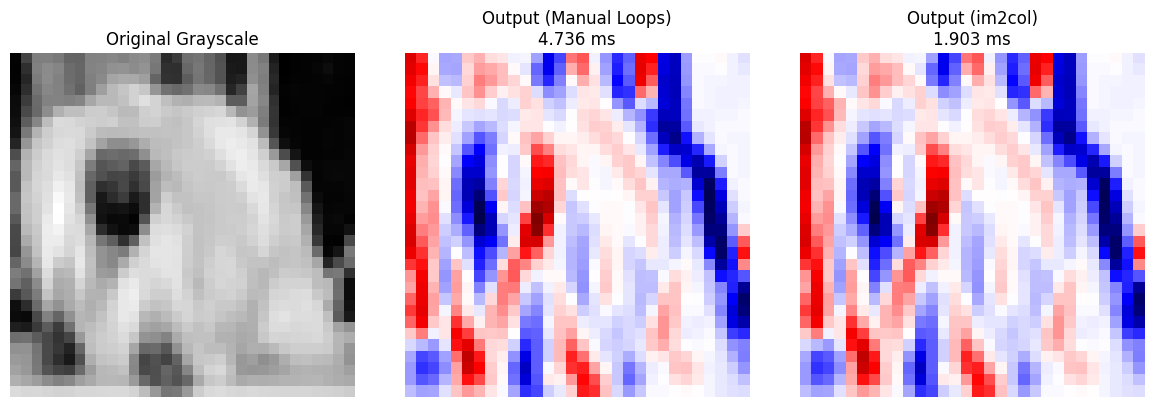

In [170]:
import time
import numpy as np
import matplotlib.pyplot as plt

idx = np.random.randint(len(x_train))
sample_img = x_train[idx].astype(np.float32)
gray_image = np.dot(sample_img, [0.2989, 0.5870, 0.1140])

kernel = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]], dtype=np.float32)

start_time = time.perf_counter()
out_manual = manual_convolution(gray_image, kernel)
time_manual = time.perf_counter() - start_time

start_time = time.perf_counter()
out_im2col = im2col_convolution(gray_image, kernel)
time_im2col = time.perf_counter() - start_time

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(gray_image, cmap='gray')
axes[0].set_title("Original Grayscale")
axes[0].axis('off')

axes[1].imshow(out_manual, cmap='seismic')
axes[1].set_title(f"Output (Manual Loops)\n{time_manual*1000:.3f} ms")
axes[1].axis('off')

axes[2].imshow(out_im2col, cmap='seismic')
axes[2].set_title(f"Output (im2col)\n{time_im2col*1000:.3f} ms")
axes[2].axis('off')

plt.tight_layout()
plt.show()


Optimization Visualization part

In [177]:
import pandas as pd
df = pd.read_csv('vehicles.csv')
df

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,...,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,...,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,...,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,...,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600


In [178]:
print(df.shape)
display(df.head(3))
print(df.dtypes)
print(df.isna().mean().sort_values(ascending=False).head(20))

(426880, 26)


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN


id                int64
url              object
region           object
region_url       object
price             int64
year            float64
manufacturer     object
model            object
condition        object
cylinders        object
fuel             object
odometer        float64
title_status     object
transmission     object
VIN              object
drive            object
size             object
type             object
paint_color      object
image_url        object
description      object
county          float64
state            object
lat             float64
long            float64
posting_date     object
dtype: object
county          1.000000
size            0.717675
cylinders       0.416225
condition       0.407852
VIN             0.377254
drive           0.305863
paint_color     0.305011
type            0.217527
manufacturer    0.041337
title_status    0.019308
lat             0.015342
long            0.015342
model           0.012362
odometer        0.010307
fuel        

In [179]:
df = df[["price","odometer"]].copy()
df = df.dropna(subset=["price","odometer"])
df

,price,odometer
27,33590,57923.0
28,22590,71229.0
29,39590,19160.0
30,30990,41124.0
31,15000,128000.0
...,...,...
426875,23590,32226.0
426876,30590,12029.0
426877,34990,4174.0
426878,28990,30112.0


In [180]:
df = df[(df["price"]>0)&(df["price"]<200_000)]
df = df[(df["odometer"]>0)&(df["odometer"]<400_000)]
df

,price,odometer
27,33590,57923.0
28,22590,71229.0
29,39590,19160.0
30,30990,41124.0
31,15000,128000.0
...,...,...
426875,23590,32226.0
426876,30590,12029.0
426877,34990,4174.0
426878,28990,30112.0


In [182]:
x_raw = np.log1p(df["odometer"].to_numpy(dtype=np.float64))
y_raw = np.log1p(df["price"].to_numpy(dtype=np.float64))

x_mu, x_sigma = x_raw.mean(), x_raw.std()
x = (x_raw - x_mu) / (x_sigma + 1e-12)
y = y_raw

n = x.shape[0]
print("n =", n)

n = 388894


In [183]:
def mse_loss(a, b, x, y):
    y_hat = a*x + b
    e = y_hat - y
    return np.mean(e**2)

def grads(a, b, x, y):
    y_hat = a*x + b
    e = y_hat - y
    da = (2.0/len(x)) * np.sum(e * x)
    db = (2.0/len(x)) * np.sum(e)
    return da, db

In [188]:
a, b = 0.0, 0.0
lr = 0.1
steps = 300

loss_hist = []
a_hist, b_hist = [], []
grad_norm_hist = []

for t in range(steps):
    L = mse_loss(a, b, x, y)
    loss_hist.append(L)
    a_hist.append(a); b_hist.append(b)

    da, db = grads(a, b, x, y)
    grad_norm_hist.append(np.sqrt(da**2 + db**2))

    a = a - lr * da
    b = b - lr * db
    
print("final a,b:", a, b) 
print("final loss:", loss_hist[-1])


final a,b: -0.2504627502889755 9.416878140226038
final loss: 1.4295600320659185


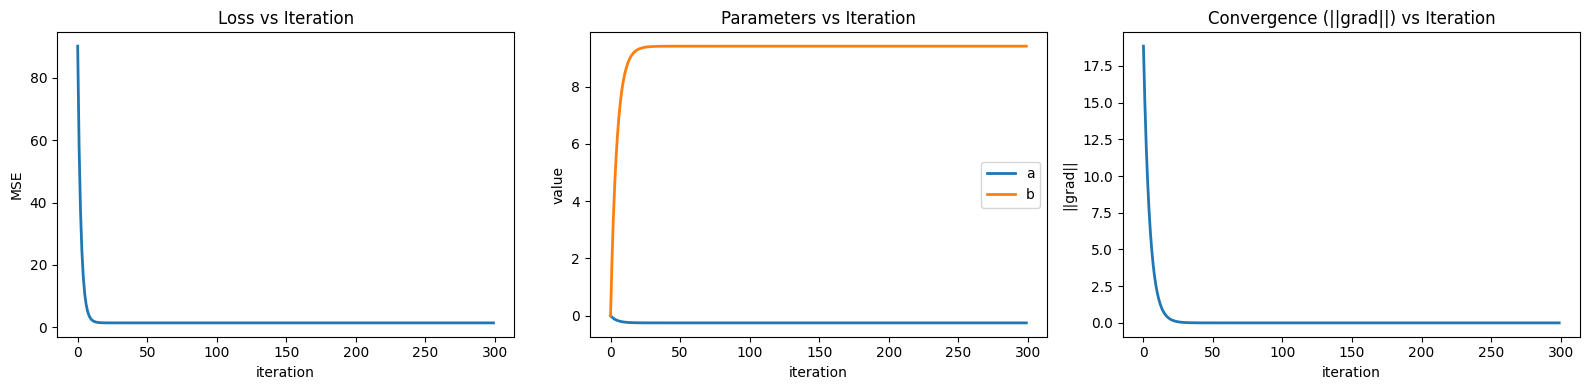

In [189]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].plot(loss_hist, lw=2)
ax[0].set_title("Loss vs Iteration")
ax[0].set_xlabel("iteration")
ax[0].set_ylabel("MSE")

ax[1].plot(a_hist, label="a", lw=2)
ax[1].plot(b_hist, label="b", lw=2)
ax[1].set_title("Parameters vs Iteration")
ax[1].set_xlabel("iteration")
ax[1].set_ylabel("value")
ax[1].legend()

ax[2].plot(grad_norm_hist, lw=2)
ax[2].set_title("Convergence (||grad||) vs Iteration")
ax[2].set_xlabel("iteration")
ax[2].set_ylabel("||grad||")

plt.tight_layout()
plt.show()
